In [47]:
%cd '/home/pxy/home/pxy/data100/fa24-student/hw/hw03'

/home/pxy/home/pxy/data100/fa24-student/hw/hw03


In [48]:
# Initialize Otter
import otter
grader = otter.Notebook("hw03_apple.ipynb")

In [49]:
# Run this cell to set up your notebook.
import warnings
warnings.simplefilter(action="ignore")

import re
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ds100_utils import *

# Ensure that pandas shows at least 280 characters in columns, so we can see full articles.
pd.set_option("max_colwidth", 280)
plt.style.use("fivethirtyeight")
sns.set()
sns.set_context("talk")

安装NLP库transformer<br>
pip install transformers

### Q1a 加载数据的前1000个字符，用`open`函数和`read`函数

In [50]:
with open("data/bloomberg_news.txt", "r") as f:
    news_text = f.read()
    q1a = news_text[:1000]
print(q1a)

[{"id":46243185,"title":"Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover","released_at":"<date>May 29 2012<\/date> <time>09:40:58<\/time>","content":"Opera Software ASA (OPERA) , the Norwegian\nmarker of Internet browsers, surged the most on record in Oslo\nafter technology website  Pocket-Lint  reported that  Facebook Inc. (FB) \nmay try to acquire the company.  Opera gained as much as 26 percent, the biggest jump since\nit first sold shares in 2004. The Oslo-based company rose 18\npercent to 40.5 kroner at 11:37 a.m., giving it a market value\nof 4.85 billion kroner ($807 million).  Opera is the last major independent browser left, with the\nothers owned by companies such as  Microsoft Corp. (MSFT) ,  Google Inc. (GOOG)  \nand  Apple Inc. (AAPL) , said Aleksander Nilsen, an analyst at Abg Sundal\nCollier in Oslo. The company has a strong balance sheet, and\ncould be an attractive target for other companies, such as\n Mountain View , California-based Google, he said.  

In [51]:
grader.check("q1a")

q1a results: All test cases passed!

### Q1b 数据的格式是？ans：JSON

In [52]:
q1b = "C"

In [53]:
grader.check("q1b")

q1b results: All test cases passed!

### Q1c 使用`pd.read_json`加载数据
1. 将数据文件夹中的‘ bloomberg_news.txt ’文件作为‘ DataFrame ’加载到变量‘ news_df ’中。
2. 设置‘ news_df ’的**索引**以对应每篇新闻文章的‘ id ’。

In [54]:
news_df = pd.read_json("data/bloomberg_news.txt").set_index("id")
news_df.head(1)

,title,released_at,content,path
id,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"Opera Software ASA (OPERA) , the Norwegian\nmarker of Internet browsers, surged the most on record in Oslo\nafter technology website Pocket-Lint reported that Facebook Inc. (FB) \nmay try to acquire the company. Opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt


In [55]:
grader.check("q1c")

q1c results: All test cases passed!

## Q2 通过分析发布日期（出版日期）与不同主题和公司之间的关系开始探索新闻文章。
### Q2a Parti
创建一个正则表达式，从‘ news_df["released_at"] ’列中提取月、日、年、小时、分钟和秒。你应该创建一个名为dates的新DataFrame，它包含：
1. 索引与‘ news_df ’ （' id '）和
2. 列标签:“Month”,“Day”,“Year”,“Hour”,“Minute”,“Second”。

此外，将所有数值（“年”、“日”、“小时”、“分钟”、“秒”）转换为类型“int”。

正则表达式：`r"<date>(.*) ([0-9]*) ([0-9]*).*<time>([0-9]*):([0-9]*):([0-9]*)`
需要注意的地方：在转换为int型时，等式左边要选择需要转换的列而不是直接用`dates`，会导致不需要转换的列丢失

In [56]:
news_df.head()

,title,released_at,content,path
id,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"Opera Software ASA (OPERA) , the Norwegian\nmarker of Internet browsers, surged the most on record in Oslo\nafter technology website Pocket-Lint reported that Facebook Inc. (FB) \nmay try to acquire the company. Opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt
73522879,Microsoft Calls Intel’s Comments on Next Windows ‘Inaccurate’,<date>May 18 2011</date> <time>22:42:40</time>,"Microsoft Corp. (MSFT) said comments made by\nan Intel Corp. (INTC) executive yesterday about future version of its\nWindows operating system were “factually inaccurate and\nunfortunately misleading.” Renee James, head of Intel’s software business, said\nyesterday that Mi...",./2008_2012_msft_bloomberg_news/icrosoft-calls-intel-s-comments-on-next-windows-inaccurate-.txt
29296500,Lawyers Raking in Cash as Campaign Spending Hits Records,<date>August 15 2012</date> <time>00:09:02</time>,"Every four years, a new mix of politicians assembles to compete for the opportunity to run for president. While the candidates’ names and faces change, the lawyers stay the same. Attorney Michael Toner began his presidential-campaign legal career in 1996 working for Republic...",./2008_2012_msft_bloomberg_news/awyers-raking-in-cash-as-campaign-spending-hits-records.txt
49799724,"Microsoft, Google Sued by Louisiana Firm Over Computer-Mapping Technology",<date>July 1 2011</date> <time>22:12:37</time>,"Microsoft Corp. (MSFT) and Google Inc. (GOOG) were\naccused of violating a Louisiana company’s patent covering\nmapping technology that helps computer users see locations in\nthree dimensions. Officials of Transcenic Inc. contend in a lawsuit that\nexecutives of Google,...",./2008_2012_msft_bloomberg_news/icrosoft-google-sued-over-technology-providing-computer-maps.txt
20739032,Yahoo Co-Founder Jerry Yang Exits Company,<date>January 18 2012</date> <time>01:20:28</time>,"Jerry Yang is exiting the Yahoo!\nInc (YHOO) . board and its management team, the latest casualty of an\noverhaul that led to the ouster of Chief Executive Officer Carol\nBartz and left the company in search of strategic options. Yang, who started Yahoo in 1995 with Dav...",./2008_2012_msft_bloomberg_news/yahoo-says-co-founder-jerry-yang-resigns.txt


In [57]:
dates = news_df['released_at'].str.extract(r"<date>(.*) ([0-9]*) ([0-9]*).*<time>([0-9]*):([0-9]*):([0-9]*)")
dates.columns = ["Month", "Day", "Year", "Hour", "Minute", "Second"]

In [58]:
dates.head()

,Month,Day,Year,Hour,Minute,Second
id,,,,,,
46243185,May,29,2012,09,40,58
73522879,May,18,2011,22,42,40
29296500,August,15,2012,00,09,02
49799724,July,1,2011,22,12,37
20739032,January,18,2012,01,20,28


In [59]:
dates[["Day", "Year", "Hour", "Minute", "Second"]] = dates[["Day", "Year", "Hour", "Minute", "Second"]].astype(int)

In [60]:
dates.dtypes

Month     object
Day        int64
Year       int64
Hour       int64
Minute     int64
Second     int64
dtype: object

In [61]:
grader.check("q2ai")

q2ai results: All test cases passed!

### Q2aii
将dates与news_df合并得到news_df_dates，使用pd.merge，为了通过测试，news_df 应该是左， dates应该是右。

In [62]:
news_df_dates = pd.merge(left=news_df, right=dates, on='id')
news_df_dates.head()

,title,released_at,content,path,Month,Day,Year,Hour,Minute,Second
id,,,,,,,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"Opera Software ASA (OPERA) , the Norwegian\nmarker of Internet browsers, surged the most on record in Oslo\nafter technology website Pocket-Lint reported that Facebook Inc. (FB) \nmay try to acquire the company. Opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt,May,29,2012,9,40,58
73522879,Microsoft Calls Intel’s Comments on Next Windows ‘Inaccurate’,<date>May 18 2011</date> <time>22:42:40</time>,"Microsoft Corp. (MSFT) said comments made by\nan Intel Corp. (INTC) executive yesterday about future version of its\nWindows operating system were “factually inaccurate and\nunfortunately misleading.” Renee James, head of Intel’s software business, said\nyesterday that Mi...",./2008_2012_msft_bloomberg_news/icrosoft-calls-intel-s-comments-on-next-windows-inaccurate-.txt,May,18,2011,22,42,40
29296500,Lawyers Raking in Cash as Campaign Spending Hits Records,<date>August 15 2012</date> <time>00:09:02</time>,"Every four years, a new mix of politicians assembles to compete for the opportunity to run for president. While the candidates’ names and faces change, the lawyers stay the same. Attorney Michael Toner began his presidential-campaign legal career in 1996 working for Republic...",./2008_2012_msft_bloomberg_news/awyers-raking-in-cash-as-campaign-spending-hits-records.txt,August,15,2012,0,9,2
49799724,"Microsoft, Google Sued by Louisiana Firm Over Computer-Mapping Technology",<date>July 1 2011</date> <time>22:12:37</time>,"Microsoft Corp. (MSFT) and Google Inc. (GOOG) were\naccused of violating a Louisiana company’s patent covering\nmapping technology that helps computer users see locations in\nthree dimensions. Officials of Transcenic Inc. contend in a lawsuit that\nexecutives of Google,...",./2008_2012_msft_bloomberg_news/icrosoft-google-sued-over-technology-providing-computer-maps.txt,July,1,2011,22,12,37
20739032,Yahoo Co-Founder Jerry Yang Exits Company,<date>January 18 2012</date> <time>01:20:28</time>,"Jerry Yang is exiting the Yahoo!\nInc (YHOO) . board and its management team, the latest casualty of an\noverhaul that led to the ouster of Chief Executive Officer Carol\nBartz and left the company in search of strategic options. Yang, who started Yahoo in 1995 with Dav...",./2008_2012_msft_bloomberg_news/yahoo-says-co-founder-jerry-yang-resigns.txt,January,18,2012,1,20,28


In [63]:
grader.check("q2aii")

q2aii results: All test cases passed!

### Q2b 分析有关不同主题和公司的文章
对于公司列表中的每家公司（如下所述），在 news_dfDataFrame 中添加一个布尔列，指示文章的 “content” 中是否提到了相应的公司。最终，您应该向 DataFrame 添加包含 True/False 值的六个新列：“amazon”、“nintendo”、“apple”、“sony”、“facebook”、“netflix”。您可以在公司列表中使用 for 循环。
注意： 在搜索关键字之前将文章的内容设为小写。

In [64]:
companies = ["amazon", "nintendo", "apple", "sony", "facebook", "netflix"]

news_df['content'] = news_df['content'].str.lower()

for company in companies:
    news_df[company] = news_df['content'].str.contains(company)

news_df.head(1)

,title,released_at,content,path,amazon,nintendo,apple,sony,facebook,netflix
id,,,,,,,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"opera software asa (opera) , the norwegian\nmarker of internet browsers, surged the most on record in oslo\nafter technology website pocket-lint reported that facebook inc. (fb) \nmay try to acquire the company. opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt,False,False,True,False,True,False


In [65]:
grader.check("q2b")

q2b results: All test cases passed!

### Q2c 将所有内容放在一起来分析不同公司的发布日期和文章数量。
创建一个名为 `company_mentions` 的新 DataFrame，其中包含 2010 年（含）之后列表`companies`中提及每家公司的文章数量。`company_mentions` 应该有六列（每家公司一列），这个 DataFrame 的索引应该是发布年份 “Year”。

In [66]:
news_df.head(1)

,title,released_at,content,path,amazon,nintendo,apple,sony,facebook,netflix
id,,,,,,,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"opera software asa (opera) , the norwegian\nmarker of internet browsers, surged the most on record in oslo\nafter technology website pocket-lint reported that facebook inc. (fb) \nmay try to acquire the company. opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt,False,False,True,False,True,False


In [67]:
news_df_dates.head(1)

,title,released_at,content,path,Month,Day,Year,Hour,Minute,Second
id,,,,,,,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"Opera Software ASA (OPERA) , the Norwegian\nmarker of Internet browsers, surged the most on record in Oslo\nafter technology website Pocket-Lint reported that Facebook Inc. (FB) \nmay try to acquire the company. Opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt,May,29,2012,9,40,58


In [68]:
news_df_dates_company = pd.merge(left=news_df, right=news_df_dates.drop(columns=['title', 'released_at', 'content', 'path']), on='id')
# news_df_dates_company.head(1)
company_mentions = news_df_dates_company[news_df_dates_company['Year'] >= 2010].groupby('Year').agg('sum').loc[:, 'amazon':'netflix']
company_mentions.head()

,amazon,nintendo,apple,sony,facebook,netflix
Year,,,,,,
2010,41,28,190,55,74,9
2011,101,29,477,104,158,43
2012,179,44,766,97,271,40
2013,152,93,687,196,238,51


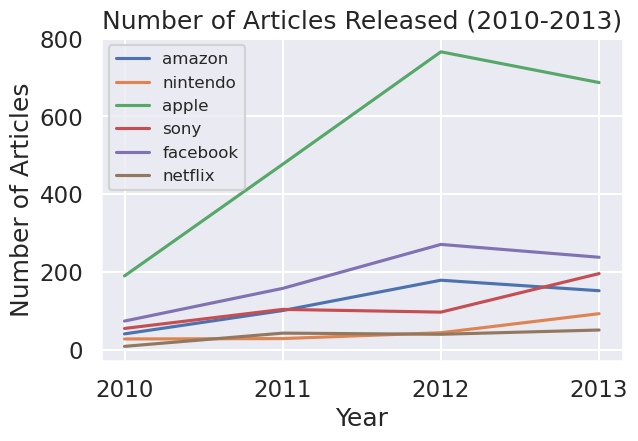

In [69]:
plt.figure(figsize=(6, 4))

for company in companies:
    sns.lineplot(data=company_mentions.reset_index(),
                 x="Year",
                 y=company,
                 label=company)
plt.legend(fontsize="12")
plt.xticks(np.arange(2010, 2014), np.arange(2010, 2014))
plt.ylabel("Number of Articles")
plt.xlabel("Year")
plt.title("Number of Articles Released (2010-2013)");

In [70]:
grader.check("q2c")

q2c results: All test cases passed!

### Q2d 发现apple在Bloomberg的文章中提及率很高，重点研究
首先将apple的股票数据加载到`aapl_stock`的DataFrame中，使用可视化进一步探索

In [71]:
aapl_stock = pd.read_csv("data/aapl_stock_daily.csv")
aapl_stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.461978,493729600
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.473151,601904800
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.370184,552160000
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.358410,477131200
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.400681,447610800


### Q2di 将`Date`列的数据类型更改为“datetime”，并将索引设置为`Date`列。然后过滤 `aapl_stock` 仅包含 2010 年至 2013 年（含）的股票数据，以便我们可以将其与2c 部分中的数据进行比较。

In [72]:
aapl_stock['Date'] = pd.to_datetime(aapl_stock['Date'])
aapl_stock = aapl_stock[(aapl_stock['Date'] >= '2010-01-01') & (aapl_stock['Date'] <= '2013-12-31')]
aapl_stock.set_index('Date', inplace=True)
aapl_stock.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.461978,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.473151,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.370184,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.358410,477131200
2010-01-08,7.510714,7.571429,7.466429,7.570714,6.400681,447610800


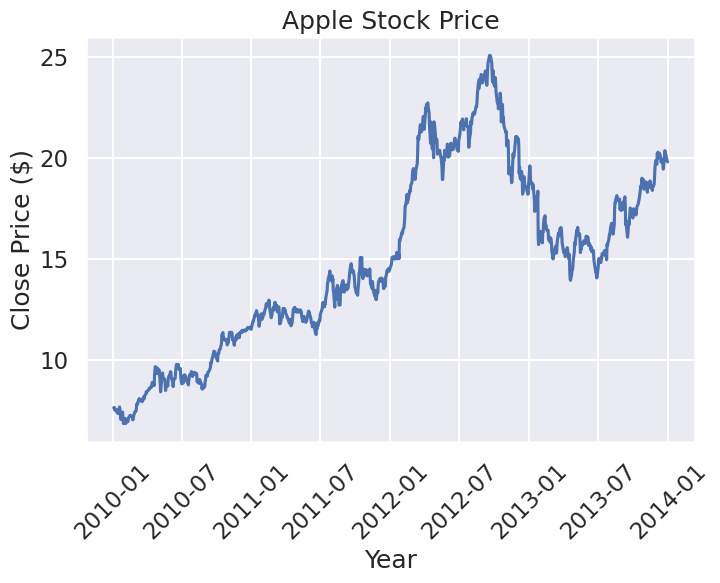

In [73]:
# Run this cell, no further action needed here.
#  可视化
plt.figure(figsize=(7,5))
sns.lineplot(data=aapl_stock.reset_index(), x='Date', y='Close')
plt.title('Apple Stock Price')
plt.ylabel('Close Price ($)')
plt.xlabel('Year');
plt.xticks(rotation=45)

plt.show()

## Q3 情感分析
使用微调版本的`DistiiBERT`模型分析`content`中的情绪

In [74]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

from transformers import pipeline
model_checkpoint = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

# Load the model
sentiment_analysis = pipeline("sentiment-analysis", model=model_checkpoint)

# Get the sentiment of a given string
sentiment_1 = sentiment_analysis("I have two dogs.")
print("Example 1: " + str(sentiment_1))

sentiment_2 = sentiment_analysis("I do not have dogs.")
print("Example 2: " + str(sentiment_2))

sentiment_3 = sentiment_analysis("Fortunately, I do not have dogs to worry about.")
print("Example 3: " + str(sentiment_3))

Device set to use cuda:0


Example 1: [{'label': 'POSITIVE', 'score': 0.9955033659934998}]
Example 2: [{'label': 'NEGATIVE', 'score': 0.9987561702728271}]
Example 3: [{'label': 'POSITIVE', 'score': 0.9975079298019409}]


模型可以确定短语/句子的情感，在0-1内展示消极或积极程度

In [75]:
sentiments = sentiment_analysis(["I have two dogs.", "I do not have dogs."])
print(sentiments)

[{'label': 'POSITIVE', 'score': 0.9955033659934998}, {'label': 'NEGATIVE', 'score': 0.9987561702728271}]


### Q3a 写一个极性得分低于0.8的句子

In [76]:
less_polar_sentence = "That are dogs."
results = sentiment_analysis(less_polar_sentence)
print(results)

[{'label': 'NEGATIVE', 'score': 0.6156660914421082}]


In [77]:
grader.check("q3a")

q3a results: All test cases passed!

### Q3b 因为在模型中运行所有文章需要一些时间，所以让我们过滤一下文章，只看关于苹果的文章。
我们目前在news_df_dates中有关于所有股票的Bloomberg文章和相应文章的日期，因此我们需要在第1部分中对其进行过滤

In [78]:
news_df_dates.head(1)

,title,released_at,content,path,Month,Day,Year,Hour,Minute,Second
id,,,,,,,,,,
46243185,Opera Jumps Most Ever After Report Facebook May Bid: Oslo Mover,<date>May 29 2012</date> <time>09:40:58</time>,"Opera Software ASA (OPERA) , the Norwegian\nmarker of Internet browsers, surged the most on record in Oslo\nafter technology website Pocket-Lint reported that Facebook Inc. (FB) \nmay try to acquire the company. Opera gained as much as 26 percent, the biggest jump since\n...",./2008_2012_msft_bloomberg_news/opera-jumps-most-on-record-after-report-of-facebook-s-interes.txt,May,29,2012,9,40,58


In [79]:
# Parti 对news_df_dates进行过滤
# 将匹配“apple”或“aapl”的正则表达式赋值给apple_re
apple_re = r"(:?apple|aapl)"
news_df_dates['title'] = news_df_dates['title'].str.lower()
aapl_news_title = news_df_dates[news_df_dates['title'].str.contains(apple_re, regex=True)]

aapl_news_title.head(1)

,title,released_at,content,path,Month,Day,Year,Hour,Minute,Second
id,,,,,,,,,,
66299939,elevation’s mcnamee says apple is winning all profit in mobile,<date>March 29 2012</date> <time>23:30:57</time>,"Technology investor Roger McNamee\nsaid all of the profit in mobile right now is being gobbled up\nby Apple Inc. (AAPL) , while Google Inc. (GOOG) and Microsoft Corp. (MSFT) are losing\nmoney in the business trying to keep up. “There is no profitability at either Micros...",./2008_2012_msft_bloomberg_news/elevation-s-mcnamee-says-apple-is-winning-all-profit-in-mobile.txt,March,29,2012,23,30,57


In [80]:
grader.check("q3bi")

q3bi results: All test cases passed!

### Q3bii
问题 3b 第二部分（Part ii）
利用 sentiment_analysis 模型，我们现在可以判断标题中提及 “apple” 或 “aapl” 的文章的情感极性。
过去，让 Data 100 课程中 1000 多名学生同时对全部标题运行该模型会给 DataHub 带来极大计算压力，甚至导致崩溃。因此，我们已经提前完成了这一步，并把下列代码的即时结果保存到 `appl_sentiment.csv` 文件：

```python
pd.DataFrame(
    sentiment_analysis(aapl_news_title["title"].tolist()),
    index=aapl_news_title.index
)
```

**请勿自行运行上述代码，** 否则可能使 DataHub 过载。

请完成以下任务：
1. 将 `data` 文件夹中的 `aapl_sentiment.csv` 读入 DataFrame，并赋值给变量 `sentiment`。
   如需回顾读入数据的方法，可参考问题 1c。
2. 将 `sentiment` 的索引设置为对应文章的 id。
   注意：模型输出同时包含 `label` 和 `score`。导入数据后，建议先观察其结构，再继续下一步。
3. 根据输出的 `label` 与 `score` 计算每条标题的情感得分：
   - 若 `label` 为 `"POSITIVE"`，情感得分直接取 `score`；
   - 若 `label` 为 `"NEGATIVE"`，情感得分取 `score` 的相反数（即负值）。
4. 在 `aapl_news_title` 中新增一列 `title_sentiment`，填入上一步计算得到的情感得分。

In [81]:
sentiment = pd.read_csv('data/aapl_sentiment.csv')
sentiment.set_index('id', inplace=True)
sentiment['title_sentiment'] = sentiment.apply(
    lambda row: row['score'] if row['label'] == 'POSITIVE' else -row['score'],
    axis=1
)
aapl_news_title['title_sentiment'] = sentiment['title_sentiment'].astype(float)

In [82]:
grader.check("q3bii")

q3bii results:
    q3bii - 1 result:
        ✅ Test case passed

    q3bii - 2 result:
        ✅ Test case passed

    q3bii - 3 result:
        ✅ Test case passed

    q3bii - 4 result:
        ❌ Test case failed
        Trying:
            aapl_news_title['title_sentiment'].iloc[1] <= 1 and aapl_news_title['title_sentiment'].iloc[1] >= -1
        Expecting:
            True
        **********************************************************************
        Line 1, in q3bii 3
        Failed example:
            aapl_news_title['title_sentiment'].iloc[1] <= 1 and aapl_news_title['title_sentiment'].iloc[1] >= -1
        Expected:
            True
        Got:
            np.True_

### Q3c 可视化`title_sentiment`的分布

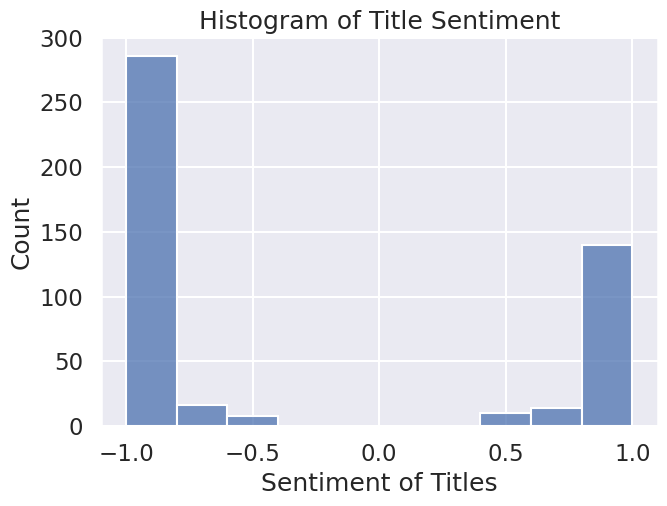

In [83]:
sns.histplot(data = aapl_news_title, x = 'title_sentiment')
plt.xlabel('Sentiment of Titles')
plt.title('Histogram of Title Sentiment')
plt.plot();

In [84]:
# Map the month names to numbers
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
# Apply the mapping to the Month column
aapl_news_title['Month'] = aapl_news_title['Month'].map(month_map)
# Ensure Year, Month, and Day are all strings
aapl_news_title['Year'] = aapl_news_title['Year'].astype(str)
aapl_news_title['Month'] = aapl_news_title['Month'].astype(str)
aapl_news_title['Day'] = aapl_news_title['Day'].astype(str)

# Combine the columns into a single date string in 'YYYY-MM-DD' format
aapl_news_title['date_str'] = aapl_news_title['Year'] + '-' + aapl_news_title['Month'] + '-' + aapl_news_title['Day']

# Convert the combined string to a datetime object using pd.to_datetime()
aapl_news_title['date'] = pd.to_datetime(aapl_news_title['date_str'], format='%Y-%m-%d', errors='coerce')



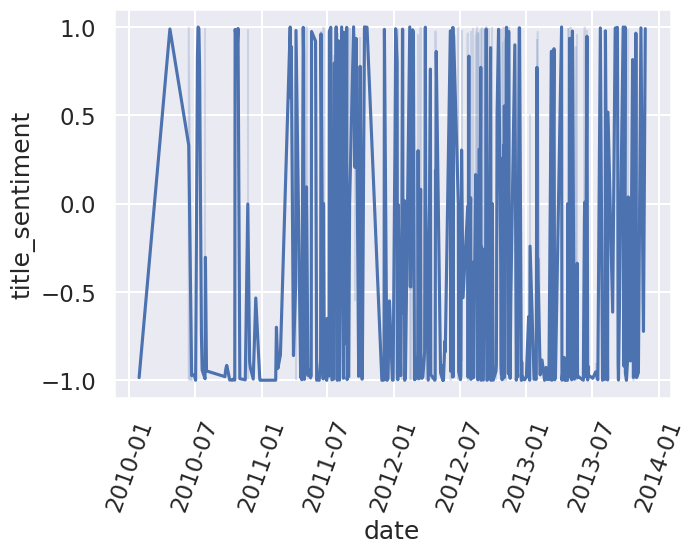

In [85]:
sns.lineplot(data = aapl_news_title, x = 'date', y = 'title_sentiment')
plt.xticks(rotation=70);

### Q3d 更好的可视化方法
1. 使用“pd。groupby 在 aapl_news_title '中找到每个年-月对的平均情绪。
2. 将结果存储在‘ monthly_avg_sentiment ’中。
3. 添加一个列“date”，用于保存每个Year-Month的datetime对象。
4. 运行单元格绘制平均值。

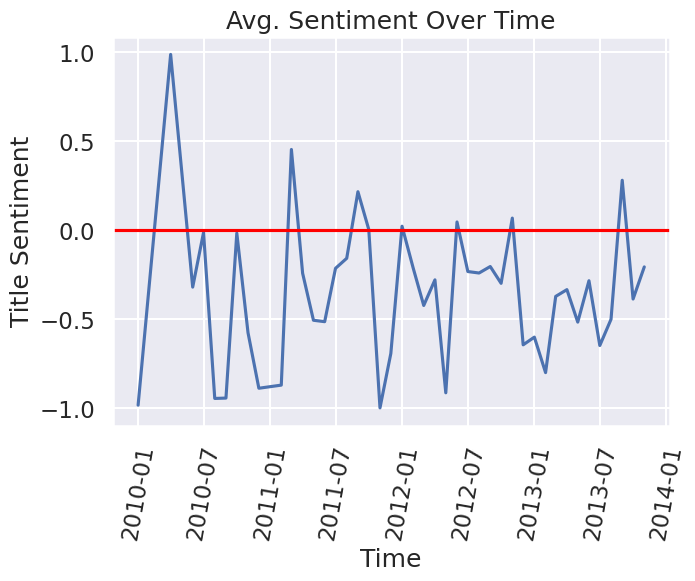

In [86]:
monthly_avg_sentiment = aapl_news_title.groupby(['Year', 'Month']).agg({'title_sentiment': 'mean'}).reset_index()
monthly_avg_sentiment['date'] = pd.to_datetime(monthly_avg_sentiment['Year'] + '-' + monthly_avg_sentiment['Month'], format='%Y-%m', errors='coerce')

# If the above are implemented correctly, running this cell should produce the graph shown above.

sns.lineplot(data = monthly_avg_sentiment, x = 'date', y = 'title_sentiment');
plt.title('Avg. Sentiment Over Time')
plt.xlabel('Time')
plt.ylabel('Title Sentiment')
plt.axhline(0, color='red')
plt.xticks(rotation = 80);

### Q3e
让我们审核一些数据，以更好地理解情感分析模型如何与我们的数据集一起工作。这是使用模型时的常见做法！将我们自己的假设与模型得出的结论进行比较是一种很好的做法，以确保我们在任务中使用了正确的模型。

### Q3ei
将‘ top_positive ’和‘ top_negative ’分别分配给包含‘ title_sentiment ’最高的五个句子和‘ title_sentiment ’最低的五个句子的数据帧。数据框应该有列“title”和“title_sentiment”。

In [87]:
top_positive = aapl_news_title.sort_values(by='title_sentiment', ascending=False).head(5)[['title', 'title_sentiment']]
top_negative = aapl_news_title.sort_values(by='title_sentiment', ascending=True).head(5)[['title', 'title_sentiment']]
display(top_positive, top_negative)

,title,title_sentiment
id,,
23913265,apple’s ios 7 is a potent upgrade: rich jaroslovsky,0.999758
6129991,"smart balance, apple, summit: intellectual property",0.999724
88792887,linear technology ahead of apple in ranking of most profitable companies,0.999680
47969077,apple’s latest iphone set to become best-selling gadget,0.999634
72640002,"apple tops $400, chases exxon as world’s most valuable company",0.999537


,title,title_sentiment
id,,
76693317,one way apple is as lame as nokia,-0.999809
48905070,"microsoft phone chief says apple ios ‘boring,’ android ‘a mess’",-0.999808
8876949,google’s android fails among businesses where apple leads,-0.999770
51528077,apple ceo ‘extremely sorry’ for iphone maps frustration,-0.999761
53508664,apple’s $145 billion in cash fails to win aaa debt rating,-0.999756


In [88]:
grader.check("q3ei")

q3ei results: All test cases passed!